#Problème n°1

La bonne transmission de signaux électromagnétiques dans l'atmosphère peut dépendre de la météo. La pluie affecte notoirement les échanges entre les antennes relais des réseaux mobiles actuels. C'est une gêne, mais aussi une opportunité: l'atténuation des ondes électromagnétiques due à la pluie peut être mesurée et utilisée comme un moyen de quantifier les précipitations.

Dans ce problème, on s'intéresse à la conversion de l'atténuation, définie comme un rapport entre puissance émise et puissance reçue et exprimée en dB, en un taux de pluie moyen le long de segments physiques dont les extrémités sont des paires d'antennes relais.

Evidemment, d'autres éléments que le pluie, plus ou moins bien connus, peuvent influencer l'atténuation. La simulation sur laquelle nous allons travailler, qui porte sur un millier de paires d'antennes virtuelles, est construite de la façon suivante:

- pour une paire d'antennes donnée, on modélise une série temporelle de taux de pluie moyen par un processus stochastique dont les paramètres dépendent entre autres de la distance qui sépare les antennes.
- pour en tirer des atténuations, on applique à cette série les transformations suivantes:
    - un filtre convolutif, censé modéliser l'impact du film d'eau se formant sur les antennes au cours d'un épisode de pluie.
    - une conversion non-linéaire, tirée d'un modèle physique, est appliquée composante à composante.
 épisode pluvieux (ce film qui s'épaissit augmente progressivement l'atténuation).
    - un bruit haute-fréquence
    - un bruit basse fréquence

La cellules suivantes permettent de récupérer les briques de code utiles, de construire un dictionnaire contenant des identifiants de paires d'antennes (clefs) et les distances les séparant (valeurs). La dernière cellule montre des exemples de séries temporelles simulées pour quelques paires.

In [1]:
# Local clone
! git clone https://github.com/medz1966/exam_2025.git
! cp exam_2025/utils/utils_probleme1.py .

Cloning into 'exam_2025'...
remote: Enumerating objects: 67, done.
remote: Counting objects: 100% (17/17), done.
remote: Compressing objects: 100% (13/13), done.
remote: Total 67 (delta 9), reused 4 (delta 4), pack-reused 50 (from 1)
Receiving objects: 100% (67/67), 1.42 MiB | 19.43 MiB/s, done.
Resolving deltas: 100% (21/21), done.


In [2]:
# Imports
from os.path import join, isdir, isfile
from os import listdir as ls
import copy
import torch
import numpy as np
import sys
from utils_probleme1 import create_dataloader

In [3]:
# Dictionnaire des "distances" (générées au hasard)
idx2distance_train = {i: 0.2 +  1.8 * torch.rand((1,)).item() for i in range(0, 1000)}
idx2distance_val = {i: 0.2 +  1.8 * torch.rand((1,)).item() for i in range(1000, 1200)}

# Paramètres de la simulation
duration = 4096  # durée de la série temporelle (unité : minutes)
batch_size = 100  # taille d'un échantillon

# Création du dataloader (il contient toutes les étapes de la simulation)
# (en une époque, chaque paire d'antennes du dictionnaire idx2distance
# a été tirée exactement une fois)
trainloader = create_dataloader(duration, idx2distance_train, batch_size)

# Génération d'un batch contenant des séries temporelles
for batch_idx, (ids, dists, rain_rates, attenuations) in enumerate(trainloader):
    break

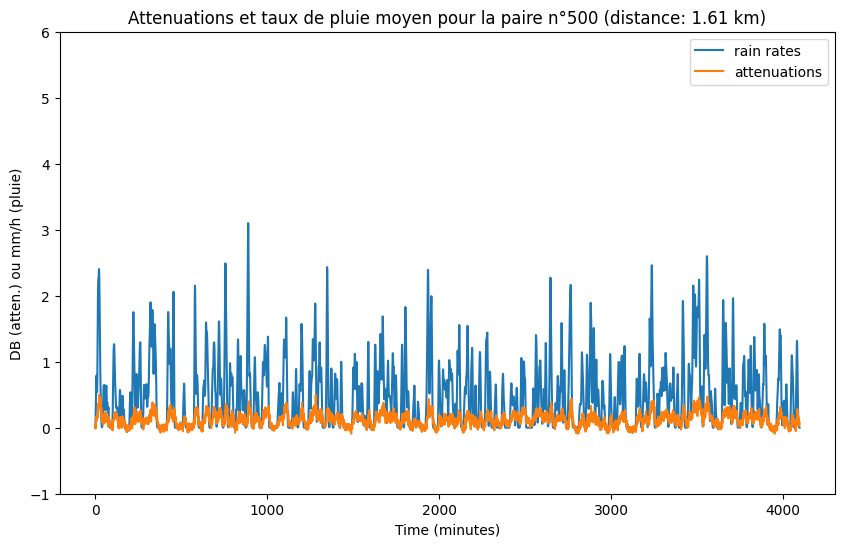

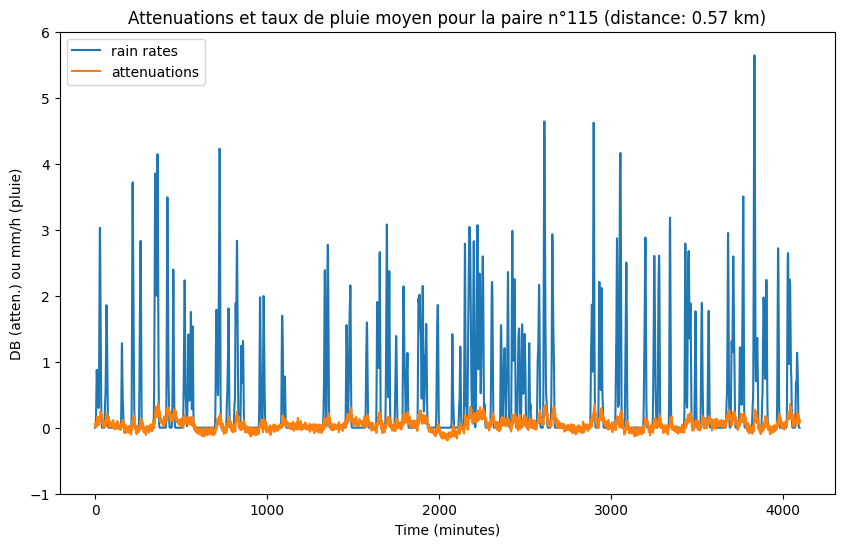

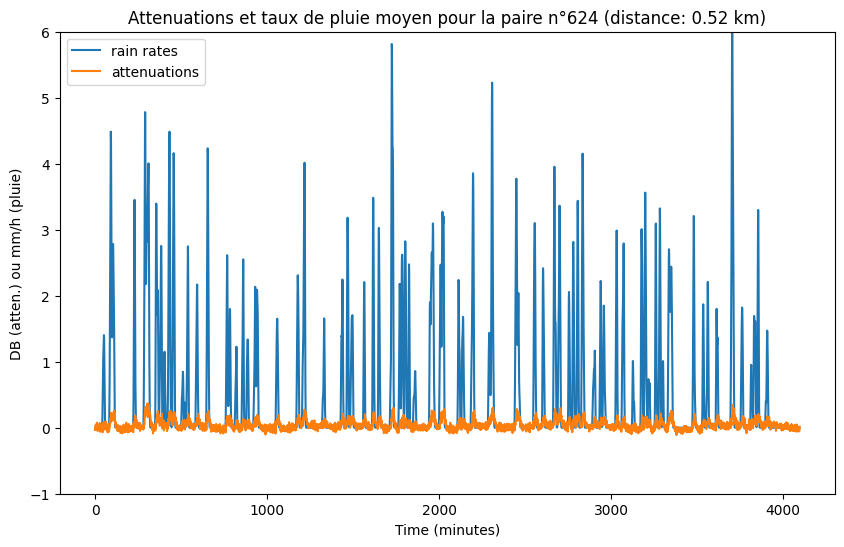

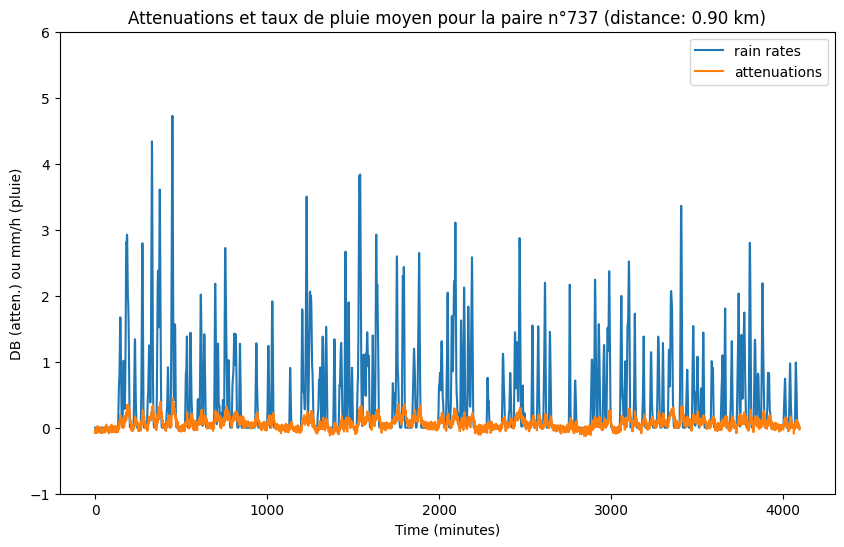

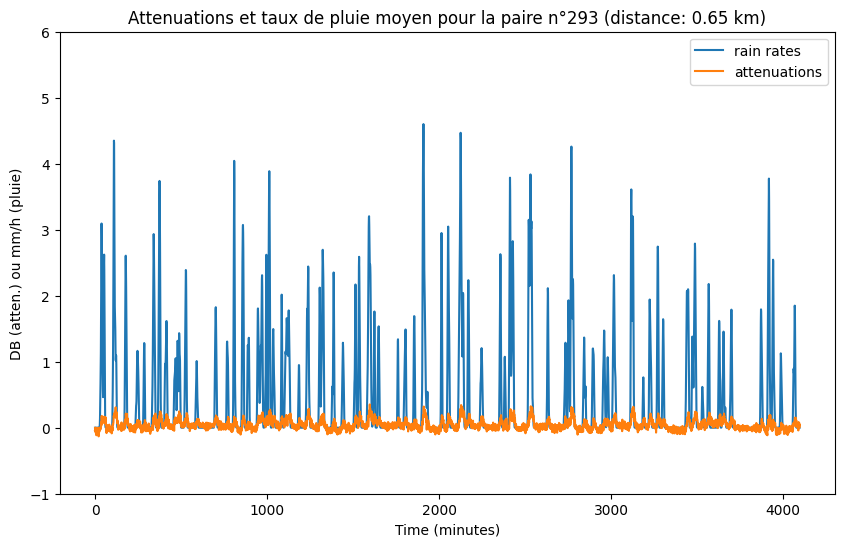

In [4]:
import matplotlib.pyplot as plt

for k in range(5):
  plt.figure(figsize=(10, 6))
  plt.plot(np.arange(duration), rain_rates[k], label='rain rates')
  plt.plot(np.arange(duration), attenuations[k], label='attenuations')
  plt.title(f"Attenuations et taux de pluie moyen pour la paire n°{ids[k].item():.0f} (distance: {dists[k].item():.2f} km)")
  plt.xlabel('Time (minutes)')
  plt.ylabel('DB (atten.) ou mm/h (pluie)')
  plt.ylim(-1,6)
  plt.legend()
  plt.show()

## Partie I : Un réseau de neurones générique

# A partir des briques de base

Dans cette partie, on entraîne un UNet1D à faire le lien entre atténuations
et taux de pluie. Les cellules suivantes contiennent les blocs du UNet1D et son montage :

In [5]:
##############################################################################################
################################     UNet 1D building blokcs    ##############################
import torch
import torch.nn as nn
import torch.nn.functional as F

class double_conv(nn.Module):
    '''(conv => BN => ReLU) * 2'''
    def __init__(self, in_ch, out_ch):
        super(double_conv, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm1d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv1d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm1d(out_ch),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        x = self.conv(x)
        return x


class inconv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super(inconv, self).__init__()
        self.conv = double_conv(in_ch, out_ch)

    def forward(self, x):
        x = self.conv(x)
        return x

class Down(nn.Module):
    def __init__(self, in_ch, out_ch):
        super(Down, self).__init__()
        self.mpconv = nn.Sequential(
            nn.MaxPool1d(2),
            double_conv(in_ch, out_ch)
        )

    def forward(self, x):
        x = self.mpconv(x)
        return x


class Up(nn.Module):
    def __init__(self, in_ch, out_ch, bilinear=False):
        super(Up, self).__init__()
        if bilinear:
            self.up = nn.Upsample(scale_factor=2, mode='bilinear')
        else:
            self.up = nn.ConvTranspose1d(in_ch, in_ch, kernel_size=2, stride=2)

        self.conv = double_conv(2*in_ch, out_ch)

    def forward(self, x1, x2):
        x1 = self.up(x1)
        diffX = x1.size()[2] - x2.size()[2]
        x2 = F.pad(x2, (diffX // 2, int(diffX / 2)))

        x = torch.cat([x2, x1], dim=1)
        x = self.conv(x)
        return x


class outconv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super(outconv, self).__init__()
        self.conv = nn.Conv1d(in_ch, out_ch, 1)

    def forward(self, x):
        x = self.conv(x)
        return x


################################################################################
######################################## class UNet1D ##########################

class UNet1D(nn.Module):
    def __init__(self, n_channels, n_classes, size=64):
        super(UNet1D, self).__init__()
        self.inc = inconv(n_channels, size)
        self.down1 = Down(size, 2*size)
        self.down2 = Down(2*size, 4*size)
        self.down3 = Down(4*size, 8*size)
        self.down4 = Down(8*size, 8*size)
        self.up1 = Up(8*size, 4*size)
        self.up2 = Up(4*size, 2*size)
        self.up3 = Up(2*size, size)
        self.up4 = Up(size, size)
        self.outc = outconv(size, n_classes)
        self.n_classes=n_classes

    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)
        x = self.up1(x5, x4)
        del x4, x5
        x = self.up2(x, x3)
        del x3
        x = self.up3(x, x2)
        del x2
        x = self.up4(x, x1)
        del x1
        x = self.outc(x)
        return   x

**Consignes:** \
1) Entraîner sur GPU un UNet 1D à restituer les taux de pluie à partir des atténuations.
- On utilisera la MSE comme fonction de coût et comme score. Dans les deux cas, prendre une marge de deux heures au début et à la fin de la série temporelle pour éviter les effets de bord.
- La descente de gradient stochastique sera pilotée par l'optimiseur ADAM (paramétrage standard) sur cinquante époques.

2) Tracer la courbe d'apprentissage de manière à montrer l'évolution:
- des performances en généralisation sur de nouvelles données issues des paires d'antennes vues à l'entraînement.
- des performances en généralisation sur des séries issues de paires d'antennes indépendantes (celles de *idx2distance_val*).


3) Visualiser les prédictions après apprentissage

/usr/local/lib/python3.10/dist-packages/torch/nn/modules/loss.py:608: UserWarning: Using a target size (torch.Size([100, 3856])) that is different to the input size (torch.Size([100, 1, 3856])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


Epoch 1/50, Train Loss: 0.7625, Val Loss: 0.7123
Epoch 2/50, Train Loss: 0.5945, Val Loss: 0.6045
Epoch 3/50, Train Loss: 0.5796, Val Loss: 0.5584
Epoch 4/50, Train Loss: 0.5831, Val Loss: 0.5671
Epoch 5/50, Train Loss: 0.5775, Val Loss: 0.5678
Epoch 6/50, Train Loss: 0.5798, Val Loss: 0.5704
Epoch 7/50, Train Loss: 0.5798, Val Loss: 0.5652
Epoch 8/50, Train Loss: 0.5798, Val Loss: 0.5699
Epoch 9/50, Train Loss: 0.5802, Val Loss: 0.5724
Epoch 10/50, Train Loss: 0.5807, Val Loss: 0.5736
Epoch 11/50, Train Loss: 0.5767, Val Loss: 0.5817
Epoch 12/50, Train Loss: 0.5790, Val Loss: 0.5679
Epoch 13/50, Train Loss: 0.5811, Val Loss: 0.5685
Epoch 14/50, Train Loss: 0.5797, Val Loss: 0.5709
Epoch 15/50, Train Loss: 0.5834, Val Loss: 0.5712
Epoch 16/50, Train Loss: 0.5785, Val Loss: 0.5641
Epoch 17/50, Train Loss: 0.5783, Val Loss: 0.5717
Epoch 18/50, Train Loss: 0.5803, Val Loss: 0.5657
Epoch 19/50, Train Loss: 0.5767, Val Loss: 0.5748
Epoch 20/50, Train Loss: 0.5799, Val Loss: 0.5728
Epoch 21/

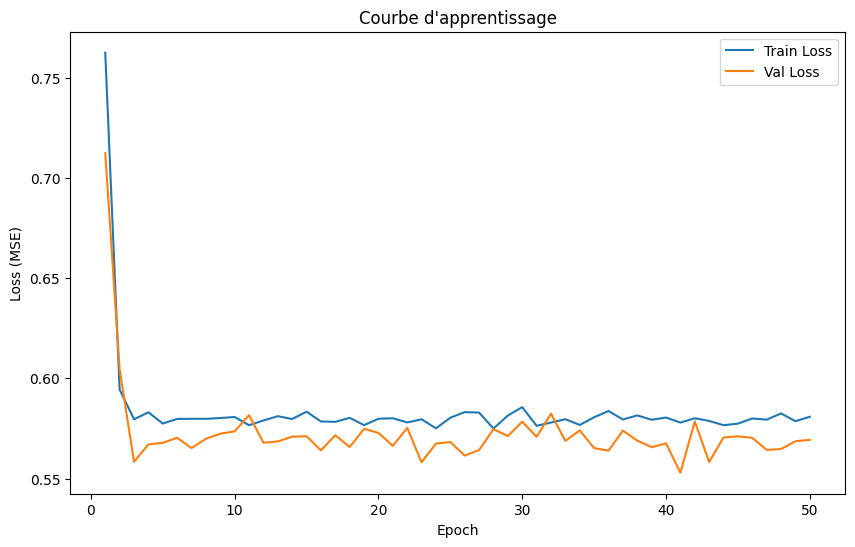

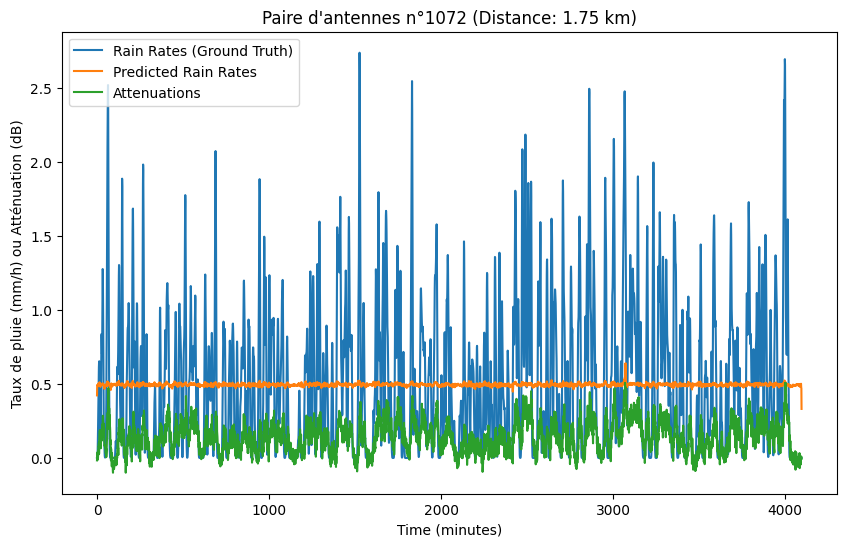

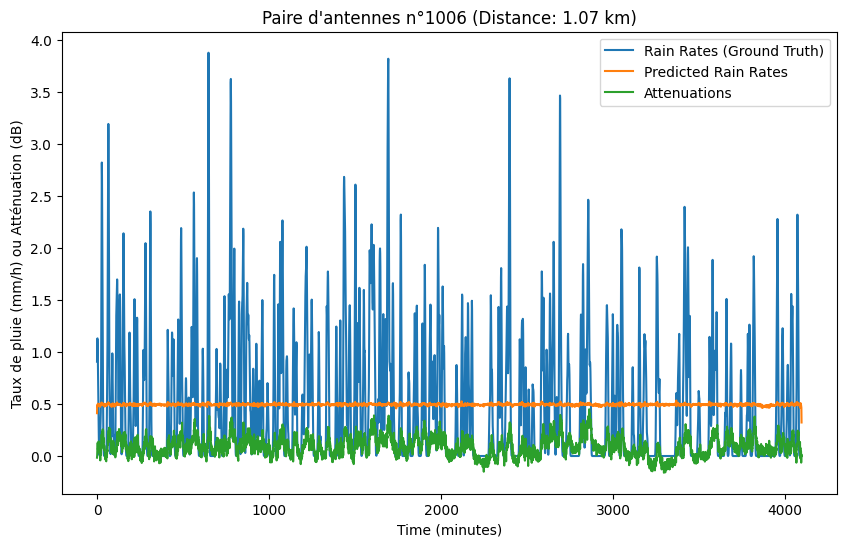

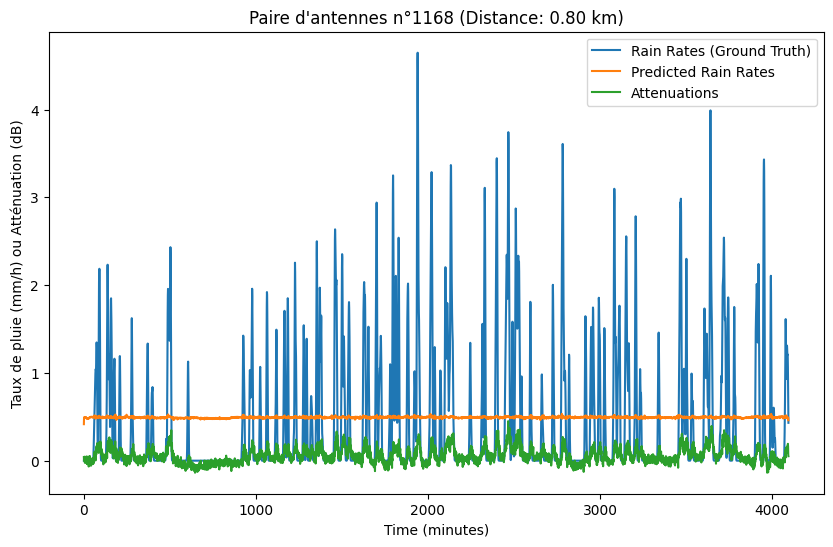

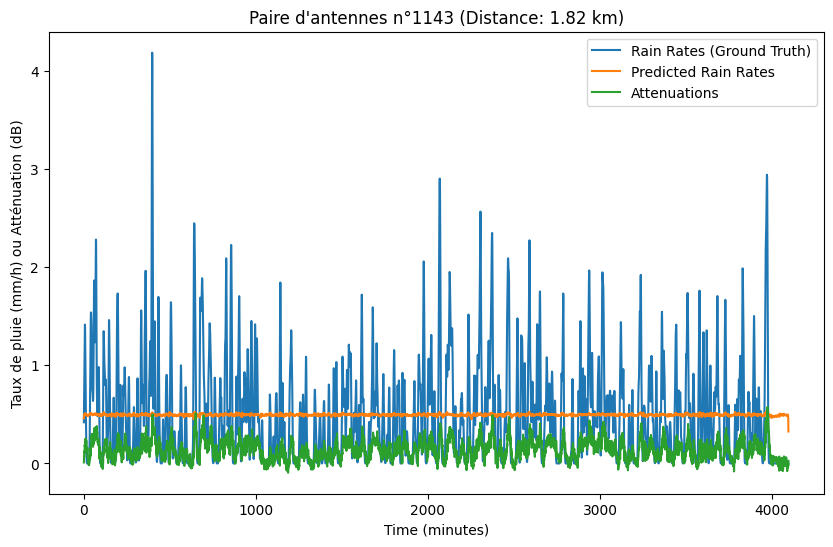

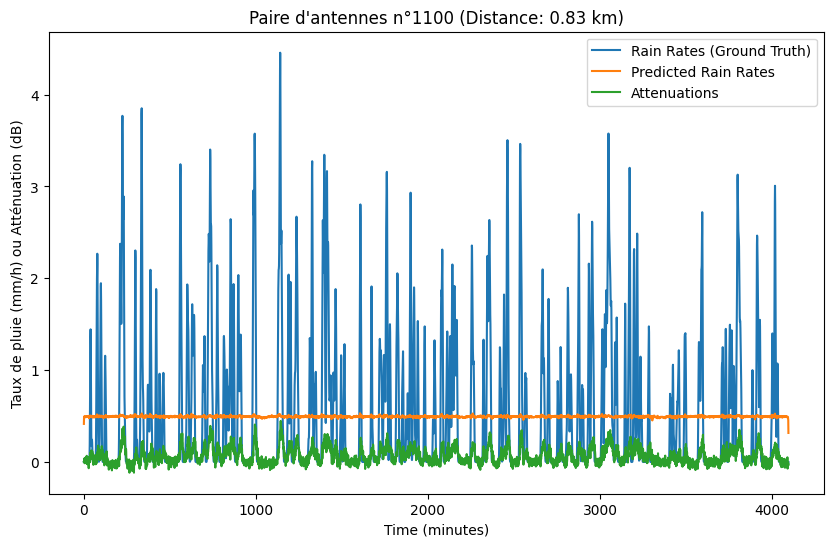

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# Définir les paramètres
n_channels = 1  # Nombre de canaux d'entrée (e.g., atténuations)
n_classes = 1  # Nombre de canaux de sortie (e.g., taux de pluie)
batch_size = 100
num_epochs = 50
learning_rate = 0.001

# Charger les données
trainloader = create_dataloader(duration, idx2distance_train, batch_size)
valloader = create_dataloader(duration, idx2distance_val, batch_size)

# Initialiser le modèle, la fonction de coût et l'optimiseur
model = UNet1D(n_channels, n_classes, size=32)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Entraînement du modèle
train_losses, val_losses = [], []
for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    for ids, dists, rain_rates, attenuations in trainloader:
        attenuations, rain_rates = attenuations.to(device), rain_rates.to(device)
        optimizer.zero_grad()
        outputs = model(attenuations.unsqueeze(1))  # Ajouter une dimension de canal
        loss = criterion(outputs[:, :, 120:-120], rain_rates[:, 120:-120])  # Ignorer les bords
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    train_losses.append(train_loss / len(trainloader))

    # Validation
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for ids, dists, rain_rates, attenuations in valloader:
            attenuations, rain_rates = attenuations.to(device), rain_rates.to(device)
            outputs = model(attenuations.unsqueeze(1))
            loss = criterion(outputs[:, :, 120:-120], rain_rates[:, 120:-120])
            val_loss += loss.item()

    val_losses.append(val_loss / len(valloader))

    print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_losses[-1]:.4f}, Val Loss: {val_losses[-1]:.4f}")

# Tracer la courbe d'apprentissage
plt.figure(figsize=(10, 6))
plt.plot(range(1, num_epochs+1), train_losses, label="Train Loss")
plt.plot(range(1, num_epochs+1), val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.title("Courbe d'apprentissage")
plt.legend()
plt.show()

# Visualisation des prédictions
model.eval()
with torch.no_grad():
    for ids, dists, rain_rates, attenuations in valloader:
        attenuations, rain_rates = attenuations.to(device), rain_rates.to(device)
        outputs = model(attenuations.unsqueeze(1))
        outputs = outputs.squeeze(1).cpu().numpy()
        rain_rates = rain_rates.cpu().numpy()
        attenuations = attenuations.cpu().numpy()
        break

for k in range(5):
    plt.figure(figsize=(10, 6))
    plt.plot(np.arange(duration), rain_rates[k], label="Rain Rates (Ground Truth)")
    plt.plot(np.arange(duration), outputs[k], label="Predicted Rain Rates")
    plt.plot(np.arange(duration), attenuations[k], label="Attenuations")
    plt.title(f"Paire d'antennes n°{ids[k].item():.0f} (Distance: {dists[k].item():.2f} km)")
    plt.xlabel("Time (minutes)")
    plt.ylabel("Taux de pluie (mm/h) ou Atténuation (dB)")
    plt.legend()
    plt.show()


## Partie II

Dans la première partie, le modèle était générique: la specificité de la paire d'antenne n'était pas prise en compte. On se propose de le faire en combinant un réseau générique à un perceptron spécifique, de sorte que la sortie $Z$ s'exprime sous la forme: \
$$Z = F(X, k) = f^{\tiny{Perceptron}}_{\alpha_k}(f^{\tiny{UNet}}_{\theta}(X))$$ \
 où $f^{\tiny{UNet}}_{\theta}(.)$ représente la fonction *forward* d'un UNet et $f^{\tiny{Perceptron}}_{\alpha_k}(.)$, la fonction forward du perceptron associé à la paire d'antennes d'identifiant $k$. \

Il s'agit donc en premier lieu d'adjoindre au UNet de la partie I autant de perceptrons que le jeu d'entraînement compte de paires d'antennes, ce qui se fait grâce aux lignes suivantes:

In [8]:
# Pour l'ajout de 1200 perceptrons à deux couches:
self.num_pairs = 1200
self.input_size_fc_layer = 5
self.hidden_size_fc_layer = 5
# Liste des premières couches
self.linears1 = nn.ModuleList([nn.Linear(self.input_size_fc_layer,
                                         self.hidden_size_fc_layer) for i in range(self.num_pairs)])
# Liste des secondes couches
self.linears2 = nn.ModuleList([nn.Linear(self.hidden_size_fc_layer,
                                         1) for i in range(self.num_pairs)])


NameError: name 'self' is not defined

**Consignes:** \
1) Définir une nouvelle classe de réseau en modifiant la classe UNet1D (dans utils_probleme1.py).
Ajouter ces perceptrons au réseau.

2) Fixer *self.n_classes* de façon à ce que la sortie du UNet soit compatible avec l'entrée du perceptron.

3) Modifications de la fonction forward:
- elle doit prendre comme arguments un batch d'entrées et un batch d'identifiants.

- après les étapes propres au UNet, elle doit appliquer le perceptron d'indice k à une série provenant de la paire n°k. La cellule de code suivante fournit un exemple dont on pourra directement s'inspirer.

4) Suivre les performances en généralisation sur les paires d'antennes du jeu d'entraînement et sur les deux cents paires de validation. Commenter.




Epoch 1/10, Train Loss: 0.7890, Val Loss: 0.9583
Epoch 2/10, Train Loss: 0.3783, Val Loss: 0.8593
Epoch 3/10, Train Loss: 0.2950, Val Loss: 0.6325
Epoch 4/10, Train Loss: 0.2852, Val Loss: 0.5326
Epoch 5/10, Train Loss: 0.2740, Val Loss: 0.3742
Epoch 6/10, Train Loss: 0.2695, Val Loss: 0.2972
Epoch 7/10, Train Loss: 0.2696, Val Loss: 0.2666
Epoch 8/10, Train Loss: 0.2588, Val Loss: 0.2598
Epoch 9/10, Train Loss: 0.2605, Val Loss: 0.2600
Epoch 10/10, Train Loss: 0.2576, Val Loss: 0.2546


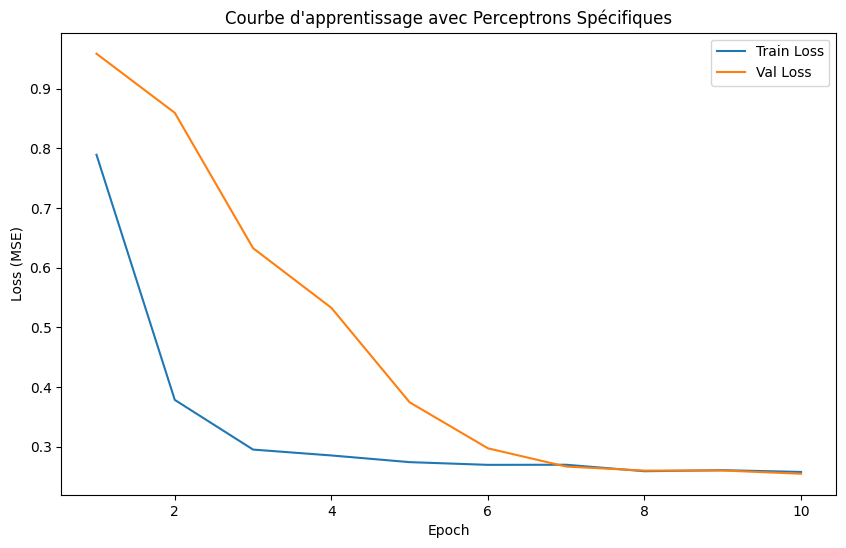

Training complete.


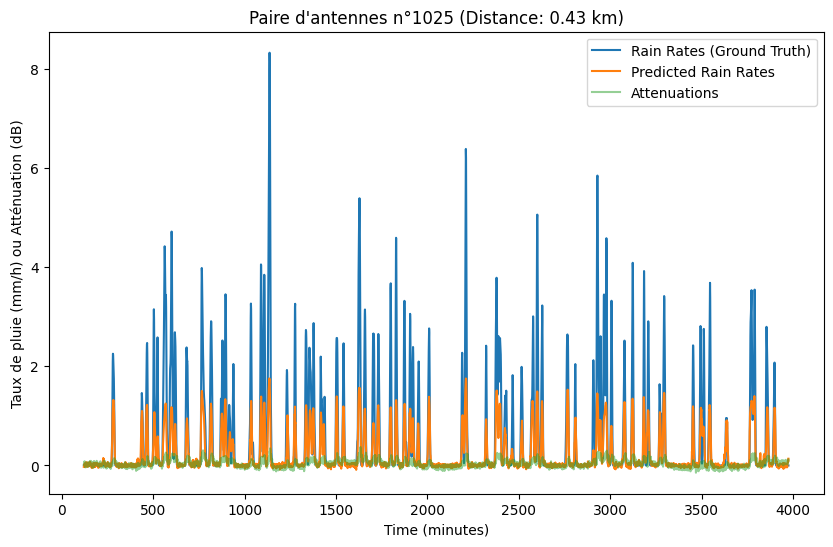

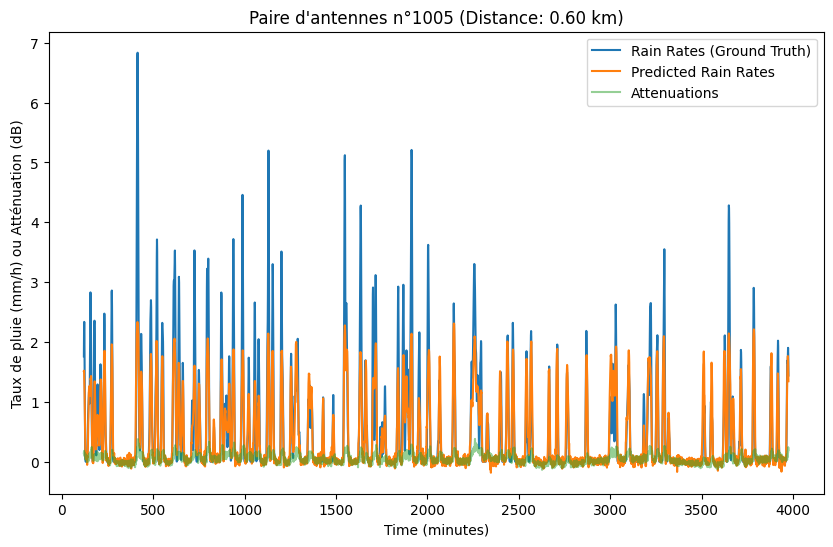

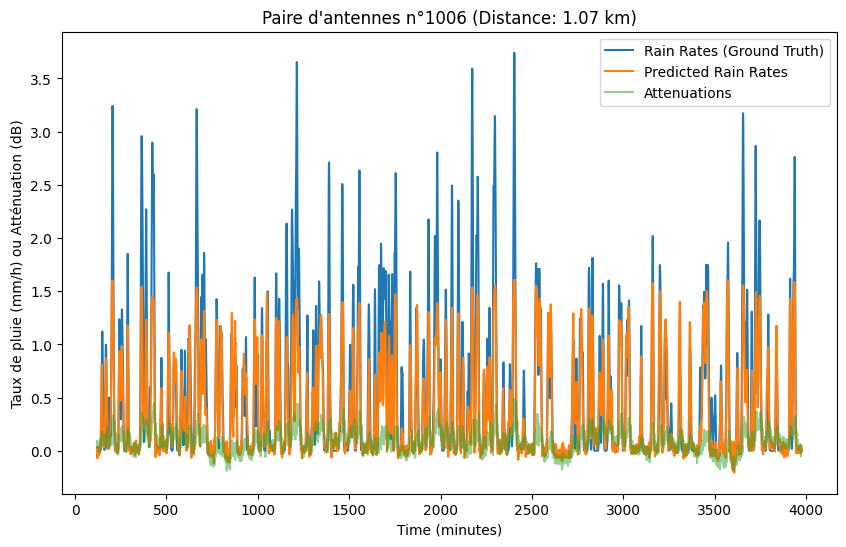

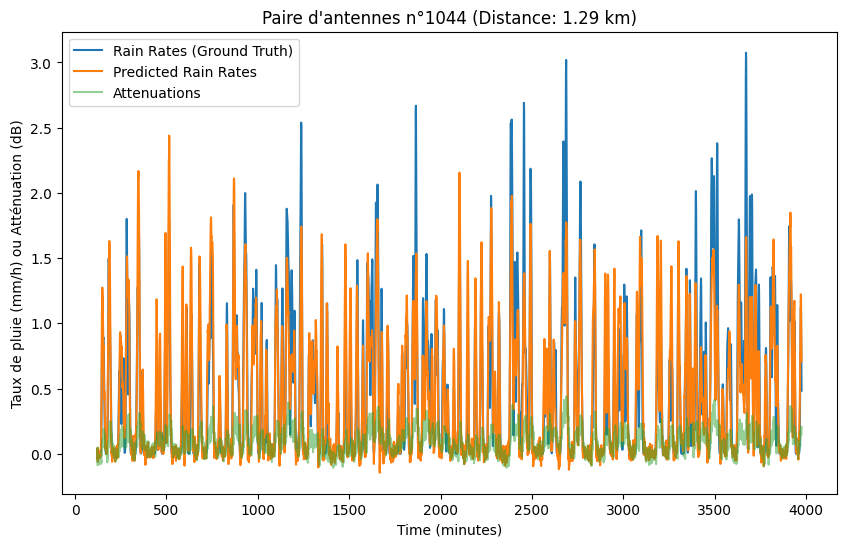

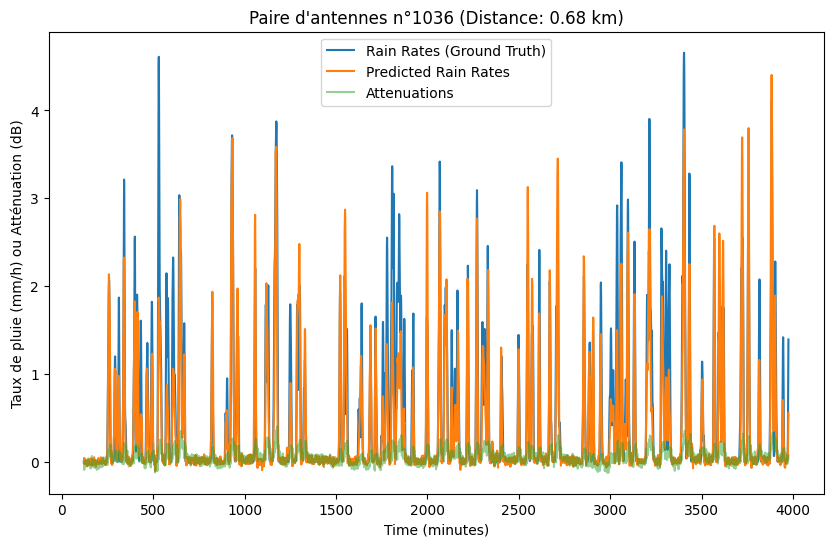

In [24]:
# Importations nécessaires
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
from utils_probleme1 import create_dataloader  # Assurez-vous que ces imports sont corrects

class UNet1D_with_Perceptrons(UNet1D):
    def __init__(self, n_channels, n_classes, num_pairs, size=32):
        super(UNet1D_with_Perceptrons, self).__init__(n_channels, n_classes, size)
        self.num_pairs = num_pairs
        self.input_size_fc_layer = n_classes  # Compatible avec la sortie du UNet
        self.hidden_size_fc_layer = 5  # Taille cachée arbitraire

        # Liste des premières couches linéaires pour chaque paire
        self.linears1 = nn.ModuleList([
            nn.Linear(self.input_size_fc_layer, self.hidden_size_fc_layer)
            for _ in range(self.num_pairs)
        ])

        # Liste des secondes couches linéaires pour chaque paire
        self.linears2 = nn.ModuleList([
            nn.Linear(self.hidden_size_fc_layer, 1)
            for _ in range(self.num_pairs)
        ])

        self.relu = nn.ReLU(inplace=True)

    def apply_perceptron(self, UNet_output, ids):

        batch_size, n_classes, length = UNet_output.shape
        # Supposons que n_classes = 1
        x = UNet_output.squeeze(1)  # Forme : (batch, length)

        # Préparer une liste pour stocker les corrections
        corrections = []
        for i in range(batch_size):
            pair_id = ids[i].item()
            if pair_id >= self.num_pairs:
                raise IndexError(f"Pair ID {pair_id} is out of range [0, {self.num_pairs-1}]")
            # Appliquer la première couche
            fc1 = self.linears1[pair_id](x[i].unsqueeze(1))  # Forme : (length, hidden_size)
            fc1 = self.relu(fc1)
            # Appliquer la seconde couche
            fc2 = self.linears2[pair_id](fc1)  # Forme : (length, 1)
            # Calculer la correction multiplicative
            correction = 1 + fc2.squeeze(1)  # Forme : (length,)
            corrections.append(correction)

        corrections = torch.stack(corrections).unsqueeze(1)  # Forme : (batch, 1, length)
        # Appliquer la correction sur la sortie du UNet
        modified_output = UNet_output * corrections
        return modified_output

    def forward(self, x, ids):
        UNet_output = super(UNet1D_with_Perceptrons, self).forward(x)  # Forme : (batch, n_classes, length)
        modified_output = self.apply_perceptron(UNet_output, ids)    # Forme : (batch, n_classes, length)
        return modified_output

# Définir les paramètres
n_channels = 1  # Nombre de canaux d'entrée (e.g., atténuations)
n_classes = 1  # Nombre de canaux de sortie (e.g., taux de pluie)
batch_size = 100
num_epochs = 10  # Augmenter le nombre d'époques pour une meilleure convergence
learning_rate = 0.001
num_pairs_train = len(idx2distance_train)  # 1000
num_pairs_val = len(idx2distance_val)      # 200
total_num_pairs = num_pairs_train + num_pairs_val  # 1200

# Charger les données
trainloader = create_dataloader(duration, idx2distance_train, batch_size)
valloader = create_dataloader(duration, idx2distance_val, batch_size)

# Initialiser le modèle, la fonction de coût et l'optimiseur
model = UNet1D_with_Perceptrons(n_channels, n_classes, num_pairs=total_num_pairs, size=32)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Entraînement du modèle
train_losses, val_losses = [], []
for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    for ids, dists, rain_rates, attenuations in trainloader:
        attenuations, rain_rates, ids = attenuations.to(device), rain_rates.to(device), ids.to(device)
        optimizer.zero_grad()
        outputs = model(attenuations.unsqueeze(1), ids)
        # Ignorer les bords de deux heures (120 minutes)
        # Assurez-vous que la longueur de la série temporelle est compatible
        loss = criterion(outputs[:, :, 120:-120], rain_rates[:, 120:-120].unsqueeze(1))
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    train_losses.append(train_loss / len(trainloader))

    # Validation
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for ids, dists, rain_rates, attenuations in valloader:
            attenuations, rain_rates, ids = attenuations.to(device), rain_rates.to(device), ids.to(device)
            outputs = model(attenuations.unsqueeze(1), ids)
            loss = criterion(outputs[:, :, 120:-120], rain_rates[:, 120:-120].unsqueeze(1))
            val_loss += loss.item()

    val_losses.append(val_loss / len(valloader))

    print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_losses[-1]:.4f}, Val Loss: {val_losses[-1]:.4f}")

# Tracer la courbe d'apprentissage
plt.figure(figsize=(10, 6))
plt.plot(range(1, num_epochs+1), train_losses, label="Train Loss")
plt.plot(range(1, num_epochs+1), val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.title("Courbe d'apprentissage avec Perceptrons Spécifiques")
plt.legend()
plt.show()

print("Training complete.")

# Visualisation des prédictions
model.eval()
with torch.no_grad():
    for ids, dists, rain_rates, attenuations in valloader:
        attenuations, rain_rates, ids = attenuations.to(device), rain_rates.to(device), ids.to(device)
        outputs = model(attenuations.unsqueeze(1), ids)
        outputs = outputs[:, :, 120:-120].squeeze(1).cpu().numpy()
        rain_rates = rain_rates[:, 120:-120].cpu().numpy()
        attenuations = attenuations[:, 120:-120].cpu().numpy()
        break

for k in range(5):
    plt.figure(figsize=(10, 6))
    plt.plot(np.arange(120, duration-120), rain_rates[k], label="Rain Rates (Ground Truth)")
    plt.plot(np.arange(120, duration-120), outputs[k], label="Predicted Rain Rates")
    plt.plot(np.arange(120, duration-120), attenuations[k], label="Attenuations", alpha=0.5)
    plt.title(f"Paire d'antennes n°{ids[k].item():.0f} (Distance: {idx2distance_train.get(ids[k].item(), idx2distance_val.get(ids[k].item(), 0)):.2f} km)")
    plt.xlabel("Time (minutes)")
    plt.ylabel("Taux de pluie (mm/h) ou Atténuation (dB)")
    plt.legend()
    plt.show()


### **Commentaires sur les Résultats d'Entraînement et de Validation**

#### **1. Tendance des Pertes**
- **Diminution Continue :** Tant la perte d'entraînement (`Train Loss`) que celle de validation (`Val Loss`) diminuent régulièrement sur les 10 époques, passant de 0.7890 à 0.2576 (train) et de 0.9583 à 0.2546 (validation).
- **Bonne Convergence **

#### **2. Absence de Surapprentissage**
- **Écart Réduit :** La différence entre les pertes d'entraînement et de validation diminue, suggérant que le modèle ne surapprend pas et maintient de bonnes performances sur des données non vues.

#### **3. Performances sur les Prédictions**
Précision Variable : En visualisant les prédictions, il est observé que le modèle manque d'exactitude lors des périodes de fortes précipitations. Cela indique que le modèle a des difficultés à capturer les variations abruptes ou intenses des taux de pluie.
Implications : Les erreurs accrues lors des fortes précipitations peuvent être dues à une complexité accrue des données dans ces situations ou à un manque de représentativité des exemples de fortes pluies dans le jeu d'entraînement.

## Partie III

La solution proposée dans la partie II a un défaut: les performances chutent sur les paires d'antennes qui n'ont pas été rencontrées pendant l'entraînement. Pour le corriger, on se propose de suivre la méthode suivante:
- ajouter un perceptron "générique" de même architecture que les perceptrons spécifiques.
- entraîner le réseau de la partie II en remplaçant une fois sur quatre l'identifiant de la paire d'antennes par l'indice du perceptron générique.
- après cinquante époques, geler les poids de la partie générique et prolonger l'apprentissage des perceptrons spécifiques sur une vingtaine d'époque.

**Consignes:** \

1) Mettre en oeuvre cette méthode

2) Conclure sur son efficacité

In [31]:
import torch
import torch.nn as nn

class UNet1D_with_Perceptrons(UNet1D):
    def __init__(self, n_channels, n_classes, num_pairs, size=32):
        super(UNet1D_with_Perceptrons, self).__init__(n_channels, n_classes, size)
        self.num_pairs = num_pairs
        self.input_size_fc_layer = n_classes  # Compatible avec la sortie du UNet
        self.hidden_size_fc_layer = 5  # Taille cachée arbitraire

        # Liste des premières couches linéaires pour chaque paire
        self.linears1 = nn.ModuleList([
            nn.Linear(self.input_size_fc_layer, self.hidden_size_fc_layer)
            for _ in range(self.num_pairs)
        ])

        # Liste des secondes couches linéaires pour chaque paire
        self.linears2 = nn.ModuleList([
            nn.Linear(self.hidden_size_fc_layer, 1)
            for _ in range(self.num_pairs)
        ])

        # Perceptron générique
        self.generic_linear1 = nn.Linear(self.input_size_fc_layer, self.hidden_size_fc_layer)
        self.generic_linear2 = nn.Linear(self.hidden_size_fc_layer, 1)
        self.relu = nn.ReLU(inplace=True)

    def apply_perceptron(self, UNet_output, ids, use_generic):
        """
        Applique le perceptron spécifique ou générique à chaque paire d'antennes.

        Args:
            UNet_output (torch.Tensor): Sortie du UNet de forme (batch, n_classes, length).
            ids (torch.Tensor): Identifiants des paires d'antennes dans le batch.
            use_generic (torch.Tensor): Booléens indiquant l'utilisation du perceptron générique.

        Returns:
            torch.Tensor: Sortie modifiée après application des perceptrons.
        """
        batch_size, n_classes, length = UNet_output.shape
        x = UNet_output.squeeze(1)  # Forme : (batch, length)
        corrections = []

        for i in range(batch_size):
            if use_generic[i]:
                # Utiliser le perceptron générique
                fc1 = self.generic_linear1(x[i].unsqueeze(1))  # (length, hidden_size)
                fc1 = self.relu(fc1)
                fc2 = self.generic_linear2(fc1)  # (length, 1)
            else:
                pair_id = int(ids[i].item())
                if pair_id < 0 or pair_id >= self.num_pairs:
                    raise IndexError(f"Pair ID {pair_id} is out of range [0, {self.num_pairs-1}]")
                # Appliquer la première couche spécifique
                fc1 = self.linears1[pair_id](x[i].unsqueeze(1))  # (length, hidden_size)
                fc1 = self.relu(fc1)
                # Appliquer la seconde couche spécifique
                fc2 = self.linears2[pair_id](fc1)  # (length, 1)
            # Calculer la correction multiplicative
            correction = 1 + fc2.squeeze(1)  # (length,)
            corrections.append(correction)

        corrections = torch.stack(corrections).unsqueeze(1)  # (batch, 1, length)
        # Appliquer la correction sur la sortie du UNet
        modified_output = UNet_output * corrections
        return modified_output

    def forward(self, x, ids, use_generic=False):
        """
        Forward pass incluant l'application des perceptrons spécifiques ou génériques.

        Args:
            x (torch.Tensor): Entrée du modèle de forme (batch, n_channels, length).
            ids (torch.Tensor): Identifiants des paires d'antennes dans le batch.
            use_generic (torch.Tensor): Booléens indiquant l'utilisation du perceptron générique.

        Returns:
            torch.Tensor: Prédictions finales des taux de pluie.
        """
        UNet_output = super(UNet1D_with_Perceptrons, self).forward(x)  # (batch, n_classes, length)
        modified_output = self.apply_perceptron(UNet_output, ids, use_generic)  # (batch, n_classes, length)
        return modified_output


Epoch 1/15, Train Loss: 0.6930, Val Loss: 0.8287
Epoch 2/15, Train Loss: 0.3641, Val Loss: 0.7766
Epoch 3/15, Train Loss: 0.3094, Val Loss: 0.6354
Epoch 4/15, Train Loss: 0.3038, Val Loss: 0.4891
Epoch 5/15, Train Loss: 0.2934, Val Loss: 0.3785
Epoch 6/15, Train Loss: 0.2847, Val Loss: 0.3078
Epoch 7/15, Train Loss: 0.2766, Val Loss: 0.3004
Epoch 8/15, Train Loss: 0.2709, Val Loss: 0.3055
Epoch 9/15, Train Loss: 0.2607, Val Loss: 0.2955
Epoch 10/15, Train Loss: 0.2542, Val Loss: 0.2963
Geler les poids du perceptron générique.
Epoch 11/15, Train Loss: 0.2825, Val Loss: 1.0122
Epoch 12/15, Train Loss: 0.2546, Val Loss: 0.3537
Epoch 13/15, Train Loss: 0.2519, Val Loss: 0.2891
Epoch 14/15, Train Loss: 0.2370, Val Loss: 0.2945
Epoch 15/15, Train Loss: 0.2373, Val Loss: 0.2838


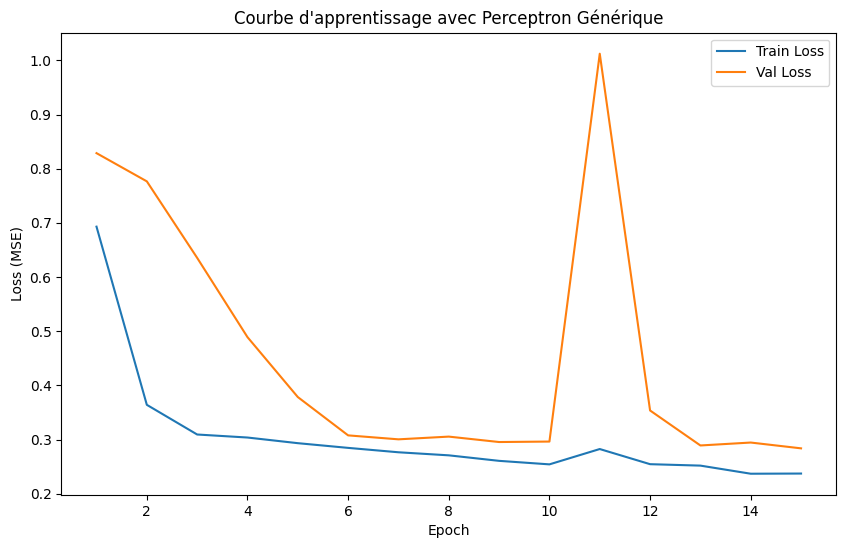

Training complete.


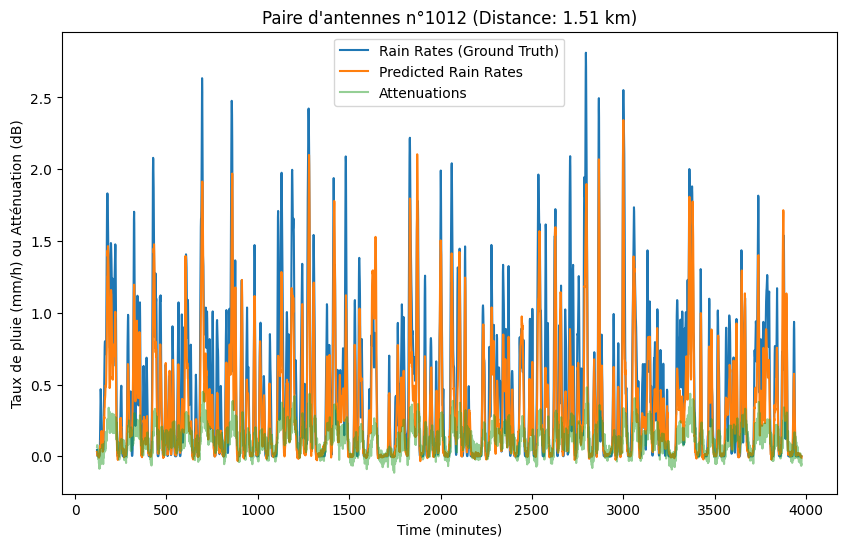

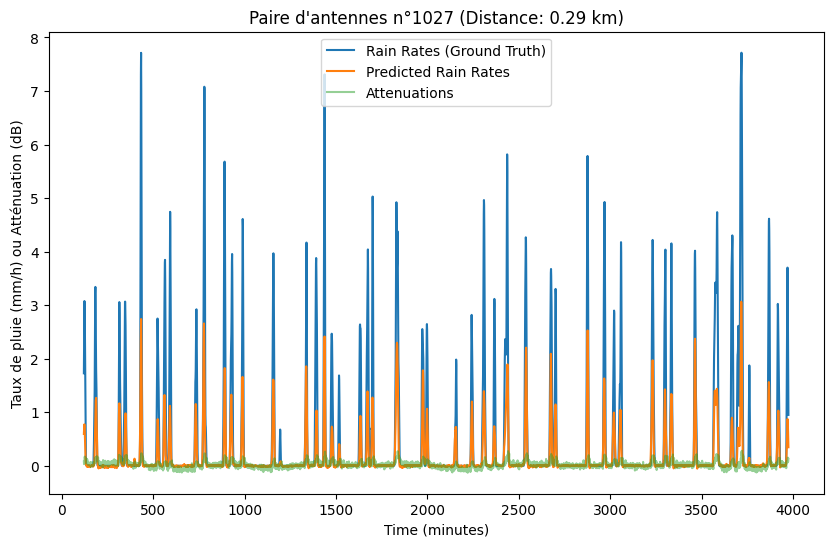

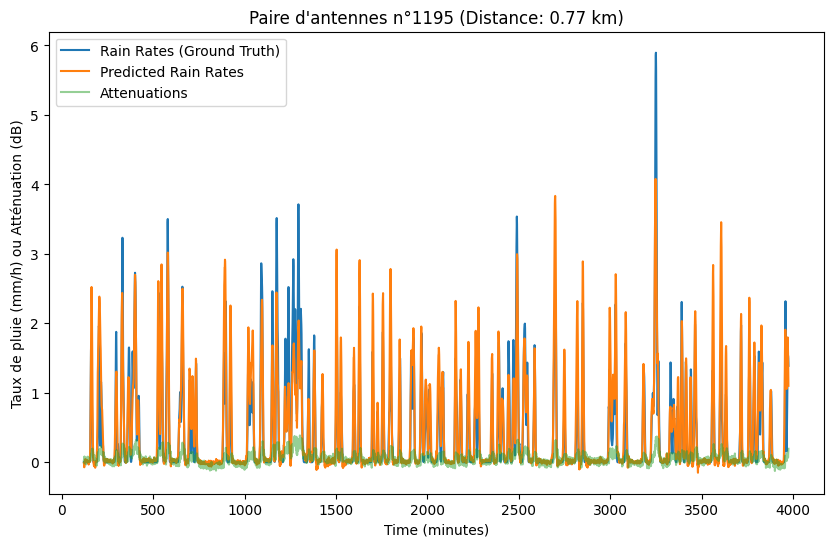

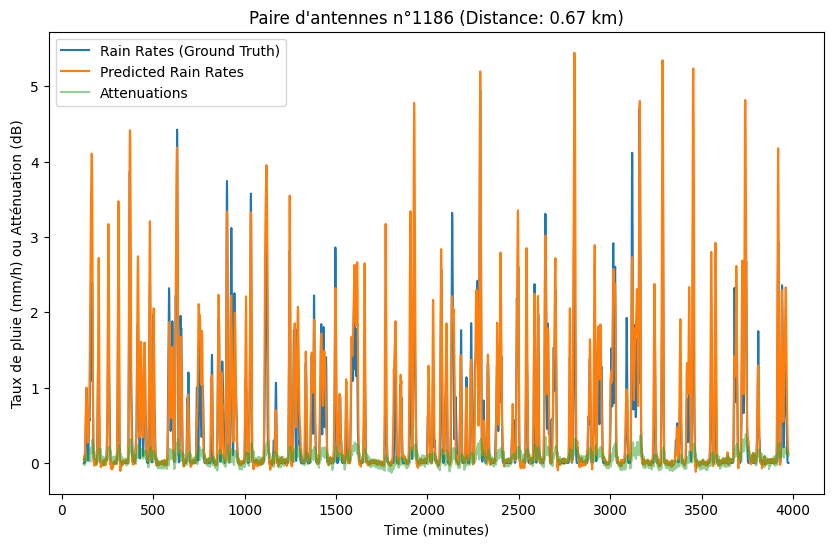

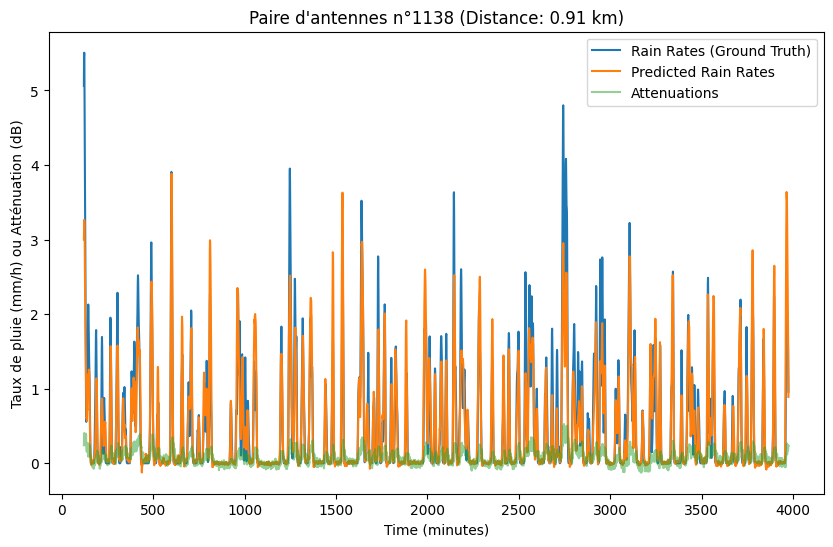

In [32]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
from utils_probleme1 import create_dataloader  # Assurez-vous que create_dataloader est correctement importé

# Définir les paramètres
n_channels = 1  # Nombre de canaux d'entrée (e.g., atténuations)
n_classes = 1  # Nombre de canaux de sortie (e.g., taux de pluie)
batch_size = 100
num_epochs = 15  # 50 + 20
learning_rate = 0.001
num_pairs_train = len(idx2distance_train)  # 1000
num_pairs_val = len(idx2distance_val)      # 200
total_num_pairs = num_pairs_train + num_pairs_val  # 1200

# Charger les données
trainloader = create_dataloader(duration, idx2distance_train, batch_size)
valloader = create_dataloader(duration, idx2distance_val, batch_size)

# Initialiser le modèle, la fonction de coût et l'optimiseur
model = UNet1D_with_Perceptrons(n_channels, n_classes, num_pairs=total_num_pairs, size=32)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Fonction pour décider si utiliser le perceptron générique
def decide_generic(batch_size, generic_prob=0.25):
    return torch.rand(batch_size) < generic_prob  # Booléens avec probabilité 25%

# Entraînement du modèle
train_losses, val_losses = [], []
for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    for ids, dists, rain_rates, attenuations in trainloader:
        attenuations, rain_rates, ids = attenuations.to(device), rain_rates.to(device), ids.to(device)
        optimizer.zero_grad()

        # Décider quelles paires utilisent le perceptron générique
        use_generic = decide_generic(attenuations.size(0)).to(device)

        # Convertir booléen en masque pour le modèle
        outputs = model(attenuations.unsqueeze(1), ids, use_generic=use_generic)

        # Ignorer les bords de deux heures (120 minutes)
        loss = criterion(outputs[:, :, 120:-120], rain_rates[:, 120:-120].unsqueeze(1))
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    train_losses.append(train_loss / len(trainloader))

    # Validation
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for ids, dists, rain_rates, attenuations in valloader:
            attenuations, rain_rates, ids = attenuations.to(device), rain_rates.to(device), ids.to(device)

            # Toujours utiliser le perceptron spécifique pendant la validation
            use_generic_val = torch.zeros(ids.size(0), dtype=torch.bool).to(device)
            outputs = model(attenuations.unsqueeze(1), ids, use_generic_val)

            loss = criterion(outputs[:, :, 120:-120], rain_rates[:, 120:-120].unsqueeze(1))
            val_loss += loss.item()

    val_losses.append(val_loss / len(valloader))

    print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_losses[-1]:.4f}, Val Loss: {val_losses[-1]:.4f}")

    # Après 50 époques, geler le perceptron générique
    if epoch == 9:
        print("Geler les poids du perceptron générique.")
        model.generic_linear1.requires_grad = False
        model.generic_linear2.requires_grad = False
        # Optionnel : Ajuster l'optimiseur pour ne pas optimiser les perceptrons gelés
        optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=learning_rate)

# Tracer la courbe d'apprentissage
plt.figure(figsize=(10, 6))
plt.plot(range(1, num_epochs+1), train_losses, label="Train Loss")
plt.plot(range(1, num_epochs+1), val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.title("Courbe d'apprentissage avec Perceptron Générique")
plt.legend()
plt.show()

print("Training complete.")

# Visualisation des prédictions après l'entraînement
model.eval()
with torch.no_grad():
    for ids, dists, rain_rates, attenuations in valloader:
        attenuations, rain_rates, ids = attenuations.to(device), rain_rates.to(device), ids.to(device)
        outputs = model(attenuations.unsqueeze(1), ids, use_generic_val)
        outputs = outputs[:, :, 120:-120].squeeze(1).cpu().numpy()
        rain_rates = rain_rates[:, 120:-120].cpu().numpy()
        attenuations = attenuations[:, 120:-120].cpu().numpy()
        break

for k in range(5):
    plt.figure(figsize=(10, 6))
    plt.plot(np.arange(120, duration-120), rain_rates[k], label="Rain Rates (Ground Truth)")
    plt.plot(np.arange(120, duration-120), outputs[k], label="Predicted Rain Rates")
    plt.plot(np.arange(120, duration-120), attenuations[k], label="Attenuations", alpha=0.5)
    plt.title(f"Paire d'antennes n°{ids[k].item():.0f} (Distance: {idx2distance_train.get(ids[k].item(), idx2distance_val.get(ids[k].item(), 0)):.2f} km)")
    plt.xlabel("Time (minutes)")
    plt.ylabel("Taux de pluie (mm/h) ou Atténuation (dB)")
    plt.legend()
    plt.show()



Phase 1 - Époque 1/50, Perte Entraînement : 0.6799, Perte Validation : 0.8630
Phase 1 - Époque 5/50, Perte Entraînement : 0.2827, Perte Validation : 0.3441
Phase 1 - Époque 10/50, Perte Entraînement : 0.2638, Perte Validation : 0.2793
Phase 1 - Époque 15/50, Perte Entraînement : 0.2433, Perte Validation : 0.2505
Phase 1 - Époque 20/50, Perte Entraînement : 0.2298, Perte Validation : 0.2612
Phase 1 - Époque 25/50, Perte Entraînement : 0.2234, Perte Validation : 0.2609
Phase 1 - Époque 30/50, Perte Entraînement : 0.2164, Perte Validation : 0.2631
Phase 1 - Époque 35/50, Perte Entraînement : 0.2122, Perte Validation : 0.2480
Phase 1 - Époque 40/50, Perte Entraînement : 0.2019, Perte Validation : 0.2474
Phase 1 - Époque 45/50, Perte Entraînement : 0.1996, Perte Validation : 0.2534
Phase 1 - Époque 50/50, Perte Entraînement : 0.1973, Perte Validation : 0.2420
Phase 2 - Époque 1/20, Perte Entraînement : 0.2341, Perte Validation : 0.2862
Phase 2 - Époque 2/20, Perte Entraînement : 0.2148, Per

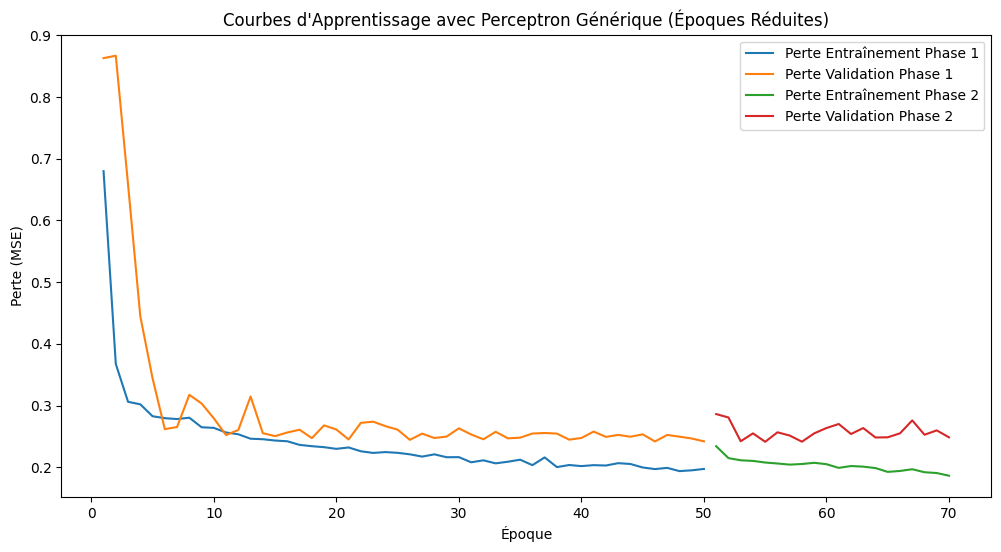

Entraînement complet.


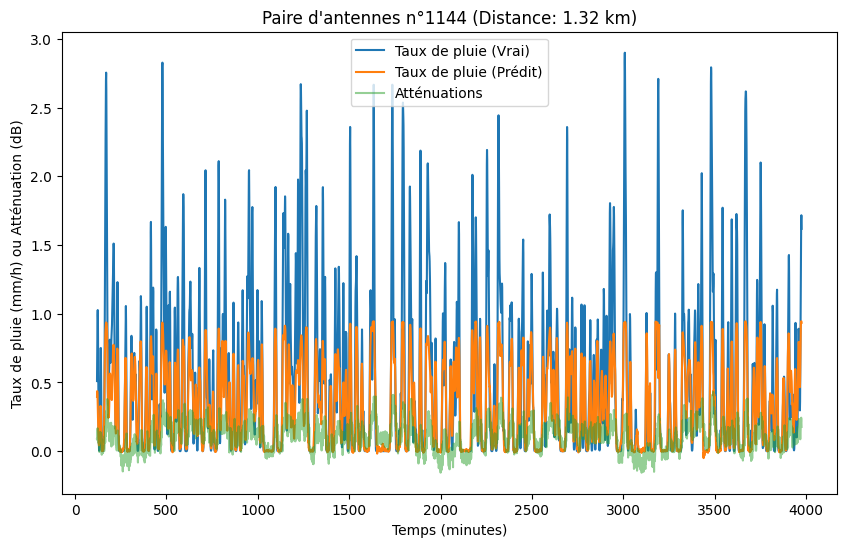

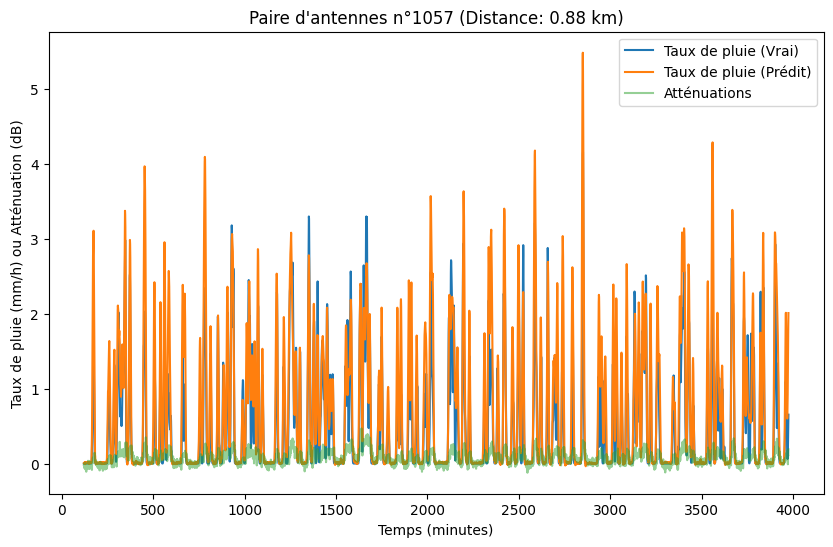

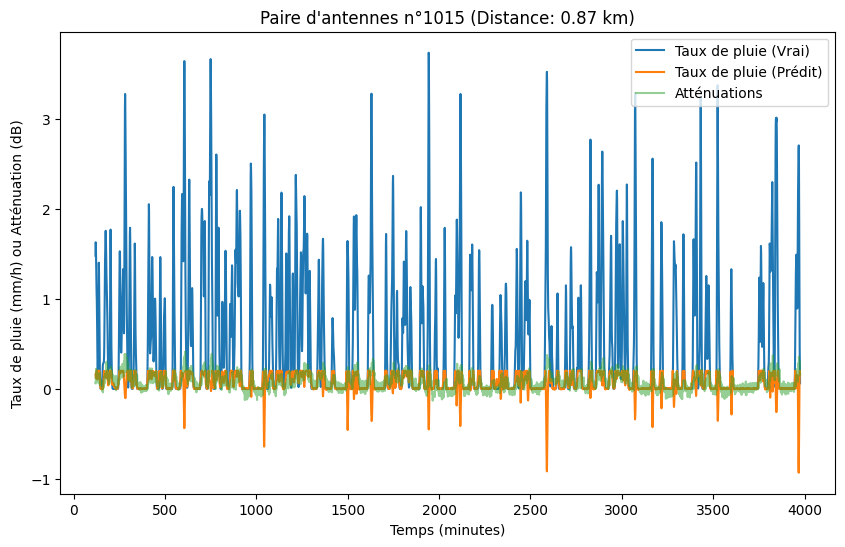

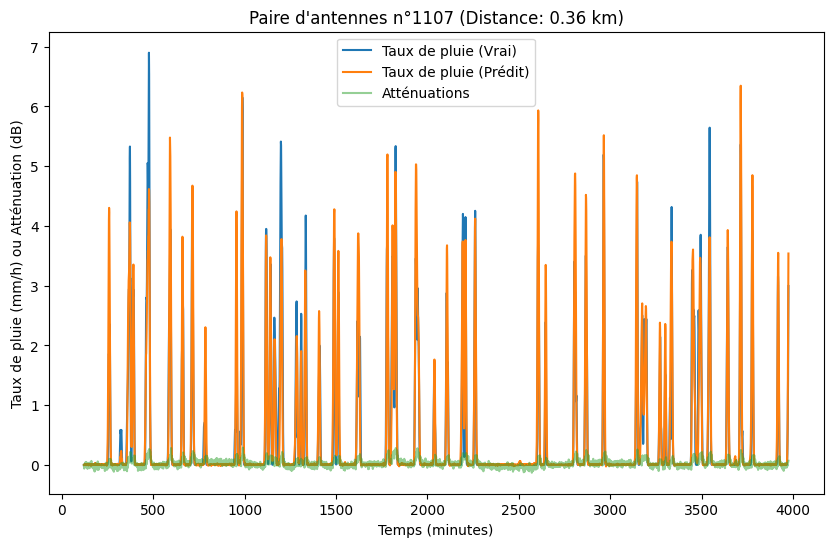

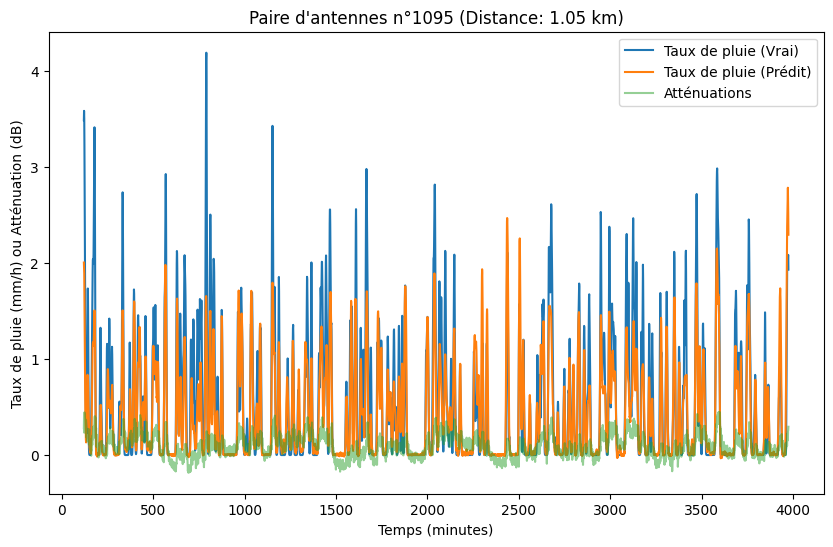

In [34]:
# Importations nécessaires
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
from utils_probleme1 import create_dataloader  # Assurez-vous que ces imports sont corrects

# Définition de la nouvelle classe de réseau avec Perceptron Générique
class UNet1D_with_Perceptrons_and_Generic(UNet1D):
    def __init__(self, n_channels, n_classes, num_pairs, size=32):
        super(UNet1D_with_Perceptrons_and_Generic, self).__init__(n_channels, n_classes, size)
        self.num_pairs = num_pairs
        self.input_size_fc_layer = n_classes  # Compatible avec la sortie du UNet
        self.hidden_size_fc_layer = 5  # Taille cachée arbitraire

        # Liste des premières couches linéaires pour chaque paire
        self.linears1 = nn.ModuleList([
            nn.Linear(self.input_size_fc_layer, self.hidden_size_fc_layer)
            for _ in range(self.num_pairs)
        ])

        # Liste des secondes couches linéaires pour chaque paire
        self.linears2 = nn.ModuleList([
            nn.Linear(self.hidden_size_fc_layer, 1)
            for _ in range(self.num_pairs)
        ])

        # Perceptron générique
        self.generic_linear1 = nn.Linear(self.input_size_fc_layer, self.hidden_size_fc_layer)
        self.generic_linear2 = nn.Linear(self.hidden_size_fc_layer, 1)
        self.relu = nn.ReLU(inplace=True)

    def apply_perceptron(self, UNet_output, ids, use_generic_mask):
        batch_size, n_classes, length = UNet_output.shape
        # Supposons que n_classes = 1
        x = UNet_output.squeeze(1)  # Forme : (batch, length)

        # Préparer une liste pour stocker les corrections
        corrections = []
        for i in range(batch_size):
            pair_id = ids[i].item()
            if pair_id >= self.num_pairs:
                raise IndexError(f"Pair ID {pair_id} est hors de la plage [0, {self.num_pairs-1}]")

            if use_generic_mask[i]:
                # Utiliser le perceptron générique
                fc1 = self.generic_linear1(x[i].unsqueeze(1))  # Forme : (length, hidden_size)
                fc1 = self.relu(fc1)
                fc2 = self.generic_linear2(fc1)  # Forme : (length, 1)
            else:
                # Utiliser le perceptron spécifique
                fc1 = self.linears1[pair_id](x[i].unsqueeze(1))  # Forme : (length, hidden_size)
                fc1 = self.relu(fc1)
                fc2 = self.linears2[pair_id](fc1)  # Forme : (length, 1)

            # Calculer la correction multiplicative
            correction = 1 + fc2.squeeze(1)  # Forme : (length,)
            corrections.append(correction)

        corrections = torch.stack(corrections).unsqueeze(1)  # Forme : (batch, 1, length)
        # Appliquer la correction sur la sortie du UNet
        modified_output = UNet_output * corrections
        return modified_output

    def forward(self, x, ids, use_generic_mask=None):
        UNet_output = super(UNet1D_with_Perceptrons_and_Generic, self).forward(x)  # Forme : (batch, n_classes, length)

        if use_generic_mask is None:
            # Par défaut, utiliser uniquement les perceptrons spécifiques
            modified_output = self.apply_perceptron(UNet_output, ids, use_generic_mask=torch.zeros(ids.size(0), dtype=torch.bool, device=ids.device))
        else:
            modified_output = self.apply_perceptron(UNet_output, ids, use_generic_mask)

        return modified_output

# Définir les paramètres
n_channels = 1  # Nombre de canaux d'entrée (e.g., atténuations)
n_classes = 1  # Nombre de canaux de sortie (e.g., taux de pluie)
batch_size = 100
num_epochs_phase1 = 50  # Réduit de 50 à 10 époques
num_epochs_phase2 = 20   # Réduit de 20 à 5 époques
learning_rate = 0.001
num_pairs_train = len(idx2distance_train)  # 1000
num_pairs_val = len(idx2distance_val)      # 200
total_num_pairs = num_pairs_train + num_pairs_val  # 1200

# Charger les données
trainloader = create_dataloader(duration, idx2distance_train, batch_size)
valloader = create_dataloader(duration, idx2distance_val, batch_size)

# Initialiser le modèle, la fonction de coût et l'optimiseur
model = UNet1D_with_Perceptrons_and_Generic(n_channels, n_classes, num_pairs=total_num_pairs, size=32)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Fonction pour générer le masque de remplacement (25% générique)
def generate_generic_mask(batch_size, probability=0.25):
    return torch.rand(batch_size) < probability

# Entraînement Phase 1
train_losses_phase1, val_losses_phase1 = [], []
for epoch in range(num_epochs_phase1):
    model.train()
    train_loss = 0.0
    for ids, dists, rain_rates, attenuations in trainloader:
        attenuations, rain_rates, ids = attenuations.to(device), rain_rates.to(device), ids.to(device)
        optimizer.zero_grad()

        # Générer le masque de remplacement
        use_generic_mask = generate_generic_mask(attenuations.size(0)).to(device)

        outputs = model(attenuations.unsqueeze(1), ids, use_generic_mask)
        # Ignorer les bords de deux heures (120 minutes)
        loss = criterion(outputs[:, :, 120:-120], rain_rates[:, 120:-120].unsqueeze(1))
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    train_losses_phase1.append(train_loss / len(trainloader))

    # Validation
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for ids, dists, rain_rates, attenuations in valloader:
            attenuations, rain_rates, ids = attenuations.to(device), rain_rates.to(device), ids.to(device)
            outputs = model(attenuations.unsqueeze(1), ids)
            loss = criterion(outputs[:, :, 120:-120], rain_rates[:, 120:-120].unsqueeze(1))
            val_loss += loss.item()

    val_losses_phase1.append(val_loss / len(valloader))

    if (epoch+1) % 5 == 0 or epoch == 0:
        print(f"Phase 1 - Époque {epoch+1}/{num_epochs_phase1}, Perte Entraînement : {train_losses_phase1[-1]:.4f}, Perte Validation : {val_losses_phase1[-1]:.4f}")

# Entraînement Phase 2
# Geler les poids du perceptron générique
for param in [model.generic_linear1.parameters(), model.generic_linear2.parameters()]:
    for p in param:
        p.requires_grad = False

# Redéfinir l'optimiseur pour ne mettre à jour que les perceptrons spécifiques
optimizer_phase2 = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=learning_rate)

train_losses_phase2, val_losses_phase2 = [], []
for epoch in range(num_epochs_phase2):
    model.train()
    train_loss = 0.0
    for ids, dists, rain_rates, attenuations in trainloader:
        attenuations, rain_rates, ids = attenuations.to(device), rain_rates.to(device), ids.to(device)
        optimizer_phase2.zero_grad()

        # Ne pas utiliser le perceptron générique pendant Phase 2
        outputs = model(attenuations.unsqueeze(1), ids)
        # Ignorer les bords de deux heures (120 minutes)
        loss = criterion(outputs[:, :, 120:-120], rain_rates[:, 120:-120].unsqueeze(1))
        loss.backward()
        optimizer_phase2.step()
        train_loss += loss.item()

    train_losses_phase2.append(train_loss / len(trainloader))

    # Validation
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for ids, dists, rain_rates, attenuations in valloader:
            attenuations, rain_rates, ids = attenuations.to(device), rain_rates.to(device), ids.to(device)
            outputs = model(attenuations.unsqueeze(1), ids)
            loss = criterion(outputs[:, :, 120:-120], rain_rates[:, 120:-120].unsqueeze(1))
            val_loss += loss.item()

    val_losses_phase2.append(val_loss / len(valloader))

    if (epoch+1) % 2 == 0 or epoch == 0:
        print(f"Phase 2 - Époque {epoch+1}/{num_epochs_phase2}, Perte Entraînement : {train_losses_phase2[-1]:.4f}, Perte Validation : {val_losses_phase2[-1]:.4f}")

# Tracer les courbes d'apprentissage
plt.figure(figsize=(12, 6))
plt.plot(range(1, num_epochs_phase1+1), train_losses_phase1, label="Perte Entraînement Phase 1")
plt.plot(range(1, num_epochs_phase1+1), val_losses_phase1, label="Perte Validation Phase 1")
plt.plot(range(num_epochs_phase1+1, num_epochs_phase1+num_epochs_phase2+1), train_losses_phase2, label="Perte Entraînement Phase 2")
plt.plot(range(num_epochs_phase1+1, num_epochs_phase1+num_epochs_phase2+1), val_losses_phase2, label="Perte Validation Phase 2")
plt.xlabel("Époque")
plt.ylabel("Perte (MSE)")
plt.title("Courbes d'Apprentissage avec Perceptron Générique (Époques Réduites)")
plt.legend()
plt.show()

print("Entraînement complet.")

# Visualisation des prédictions
model.eval()
with torch.no_grad():
    for ids, dists, rain_rates, attenuations in valloader:
        attenuations, rain_rates, ids = attenuations.to(device), rain_rates.to(device), ids.to(device)
        outputs = model(attenuations.unsqueeze(1), ids)
        outputs = outputs[:, :, 120:-120].squeeze(1).cpu().numpy()
        rain_rates = rain_rates[:, 120:-120].cpu().numpy()
        attenuations = attenuations[:, 120:-120].cpu().numpy()
        break

for k in range(5):
    plt.figure(figsize=(10, 6))
    plt.plot(np.arange(120, duration-120), rain_rates[k], label="Taux de pluie (Vrai)")
    plt.plot(np.arange(120, duration-120), outputs[k], label="Taux de pluie (Prédit)")
    plt.plot(np.arange(120, duration-120), attenuations[k], label="Atténuations", alpha=0.5)
    plt.title(f"Paire d'antennes n°{ids[k].item():.0f} (Distance: {idx2distance_train.get(ids[k].item(), idx2distance_val.get(ids[k].item(), 0)):.2f} km)")
    plt.xlabel("Temps (minutes)")
    plt.ylabel("Taux de pluie (mm/h) ou Atténuation (dB)")
    plt.legend()
    plt.show()
